In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from numpy._core.defchararray import lower

# Dataset Description



In [ ]:
# upload data and observe the data contents

df_superstore = pd.read_csv('/content/df_superstore.csv')
df_superstore.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# View dataset information
df_superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

**Dataframe df_superstore**

---
| Column | Description
| :--- | :---
| Row ID | ...
| Order ID | ID unik pesanan / order
| Order Date | Tanggal pemesanan produk
| Ship Date | Tanggal pengiriman produk
| Ship Mode | Metode pengiriman produk
| Customer ID | ID unik customer
| Customer Name | Nama customer
| Segment | Segementasi customer
| Country | Negara customer
| City | Kota customer
| State | Negara bagian customer
| Postal Code | Kode pos customer
| Region | Wilayah customer
| Product ID | ID unik produk
| Category | Kategori produk
| Sub-Category | sub kategori produk
| Product Name | Nama produk
| Sales | Total nilai penjualan per transaksi (dalam USD)
| Quantity | Jumlah unit produk yang dibeli
| Discount | Diskon yang diberikan
| Profit | Keuntungan/laba dari transaksi (dalam USD)



Dataset df_superstore ini merepresentasikan 9.994 transaksi penjualan perusahaan. Data ini mencakup informasi lengkap pemesanan produk, informasi identitas customer, dan informasi terkait produk.

Secara keseluruhan, dataset ini dapat digunakan untuk menganalisis perilaku belanja pelanggan, efektivitas program loyalitas dan promosi, performa pengiriman, serta tingkat kepuasan pelanggan terhadap layanan dan pengalaman belanja.



# Change Data Type

In [ ]:
df_superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Berdasarkan informasi dataset, terdapat tipe data yang perlu diubah seperti order date dan ship date.

Kedua kolom ini terbaca sebagai tipe data string atau object, yang seharusnya terbaca sebagai datetime karena order date merupakan tanggal pemesanan produk, dan ship date merupakan tanggal pengiriman produk tersebut

In [ ]:
# Group the column
date_columns = ['Order Date', 'Ship Date']

In [ ]:
# Change the data type
df_superstore[date_columns] = df_superstore[date_columns].apply(pd.to_datetime)
df_superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# EDA

In [ ]:
df_superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
# Check for missing value
df_superstore.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Check for duplicate data
df_superstore.duplicated().sum()

np.int64(0)

Berdasarkan hasil pengecekan missing value dan data duplikat, tidak ditemukan missing value dan data yang duplikat, sehingga tidak dilakukan handling missing value dan duplicate data

## Handling Outlier


In [ ]:
# Grouping numeric data to see data distribution
numerical_col = ['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']

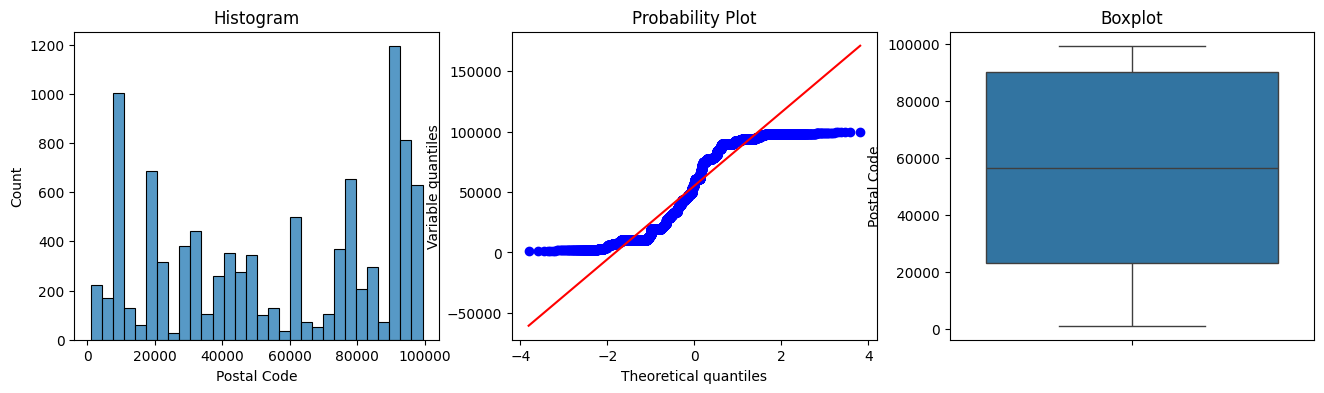

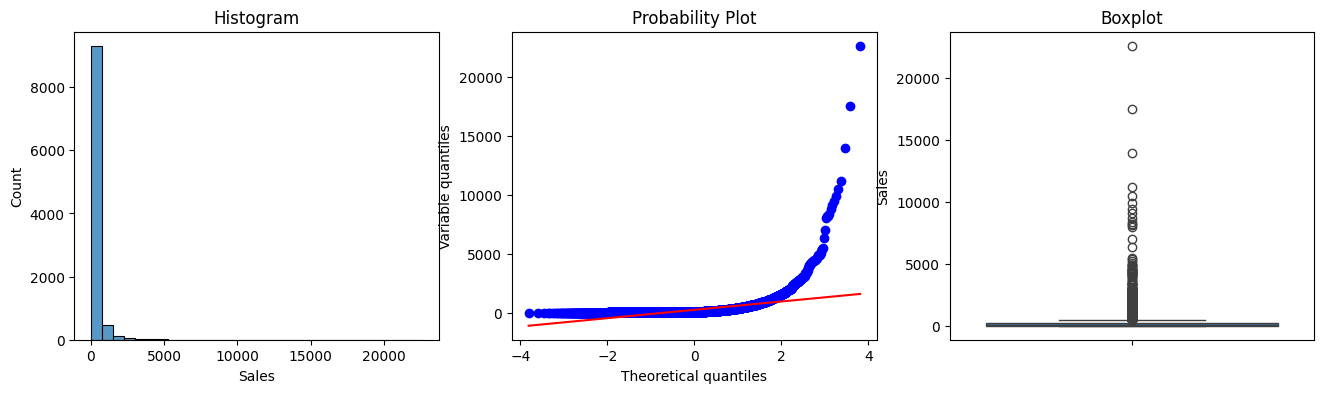

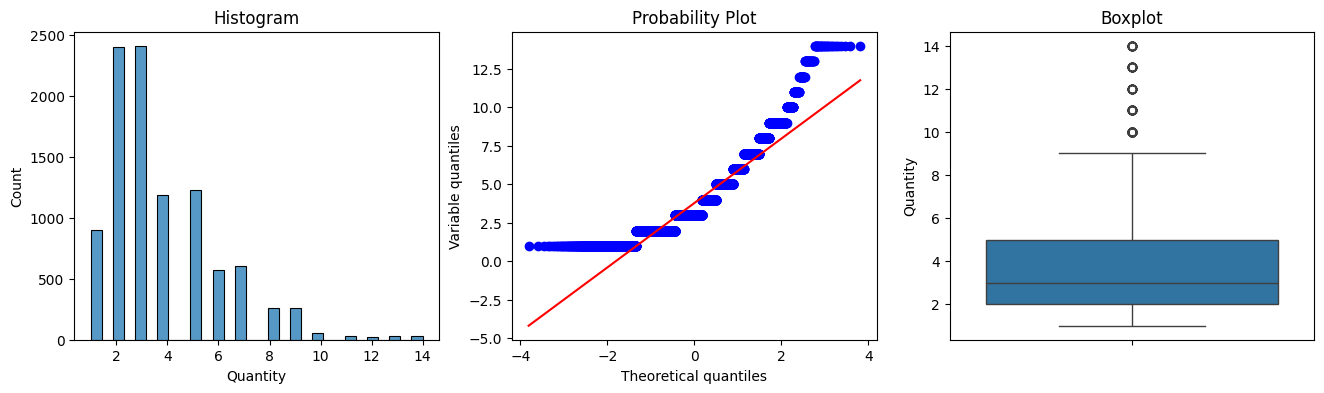

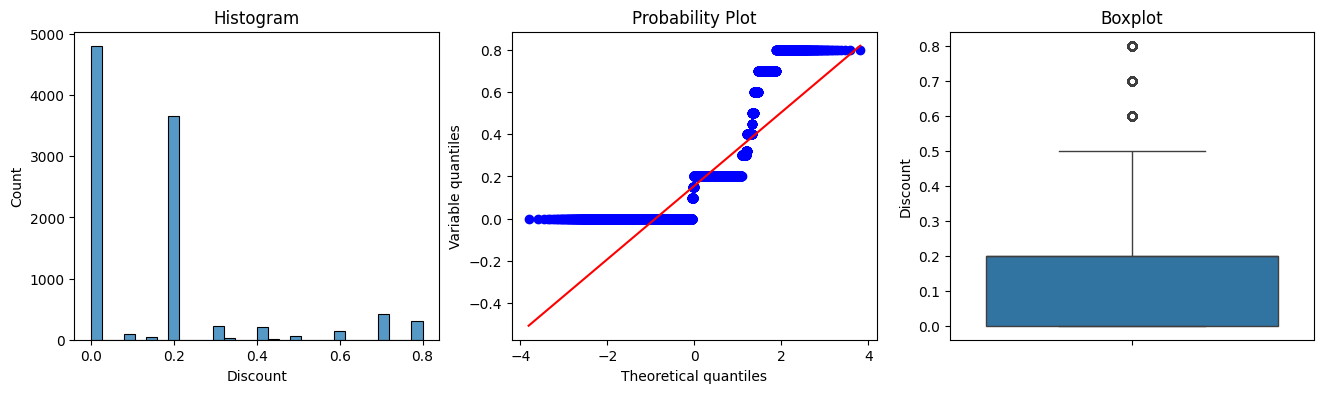

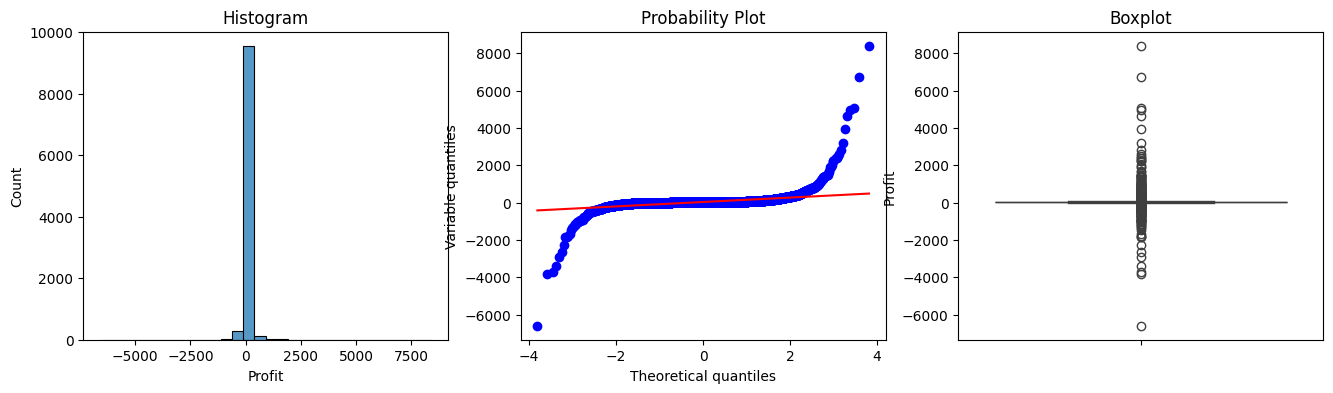

In [ ]:
def check_plot(df_superstore, variable):

    plt.figure(figsize=(16, 4))

    # Visualisasi Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df_superstore[variable], bins=30)
    plt.title('Histogram')

    # Visualisasi Q-Q Plot
    plt.subplot(1, 3, 2)
    stats.probplot(df_superstore[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # Visualisasi Box Plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df_superstore[variable])
    plt.title('Boxplot')

    plt.show()

for col in numerical_col:
  check_plot(df_superstore, col)

berdasarkan analisis distribusi, terdapat outlier yang cukup ekstrem pada kolom Sales dan Profit, sehingga perlu dilakukan handling outlier terhadap kolom sales dan profit.

Handling outlier dilakukan dengan metode konservatif. Metode konservatif dipilih karena pendekatan ini tidak banyak menghapus data, sehingga struktur distribusi asli tetap terjaga dan risiko kehilangan informasi penting dapat diminimalkan. Metode ini hanya menghilangkan atau membatasi data yang berada pada ekor distribusi ekstrem, misalnya di bawah persentil 5% dan di atas persentil 95%. Dengan demikian, outlier yang benar-benar tidak wajar dapat dikendalikan tanpa mengorbankan terlalu banyak observasi yang valid.

Metode ini cocok digunakan pada analisis seperti RFM atau segmentasi pelanggan, karena menjaga representasi populasi pelanggan tetap akurat sambil mengurangi efek distorsi dari nilai ekstrem.  

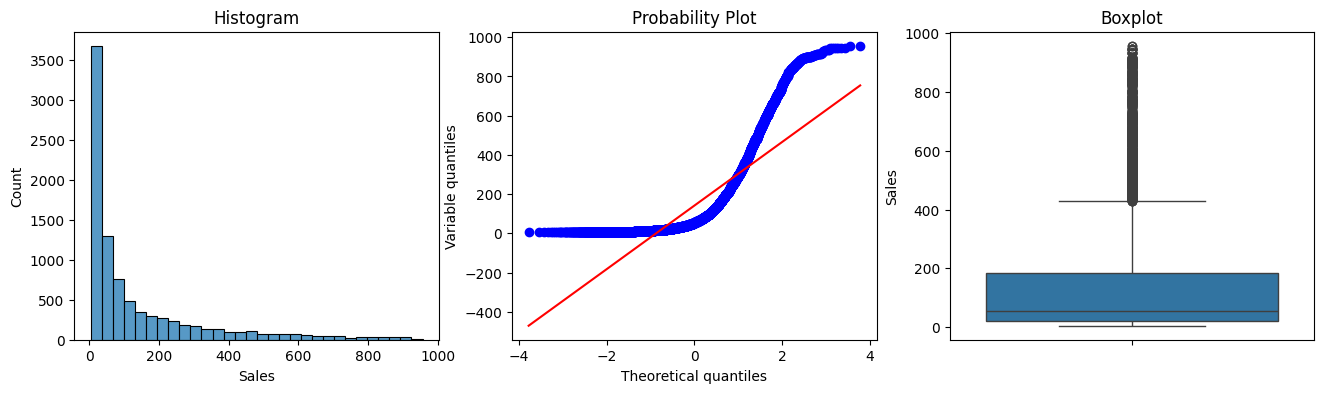

In [ ]:
#handling outlier in sales
for col in ['Sales']:
  # determine threshold
  upper_threshold = df_superstore[col].quantile(0.95)
  lower_threshold = df_superstore[col].quantile(0.05)
  # Remove from training set
  df_filtered = df_superstore[
        (df_superstore[col] <= upper_threshold) &
        (df_superstore[col] >= lower_threshold)
    ]
  check_plot(df_filtered, col)

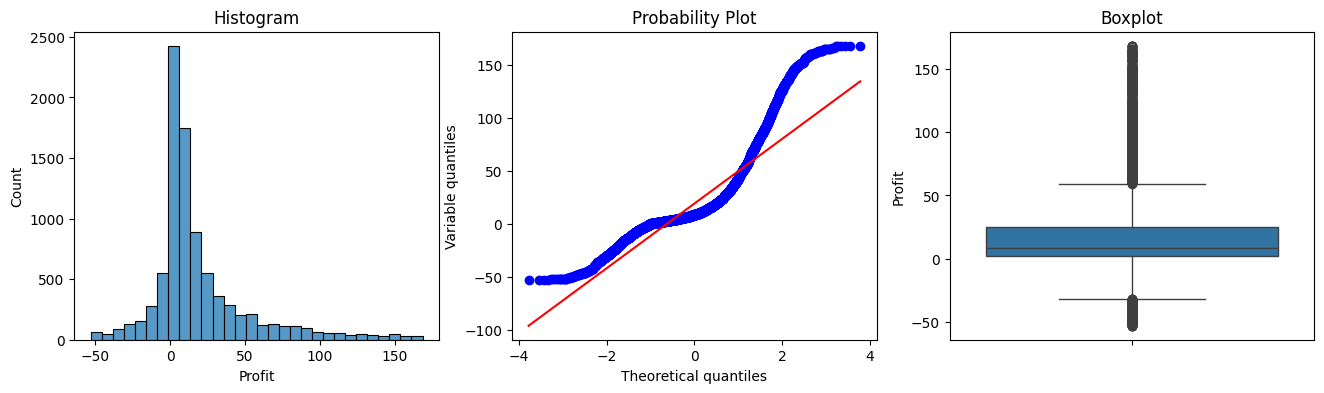

In [ ]:
#handling outlier in sales
for col in ['Profit']:
  # determine threshold
  upper_threshold = df_superstore[col].quantile(0.95)
  lower_threshold = df_superstore[col].quantile(0.05)
  # Remove from training set
  df_filtered = df_superstore[
        (df_superstore[col] <= upper_threshold) &
        (df_superstore[col] >= lower_threshold)
    ]
  check_plot(df_filtered, col)

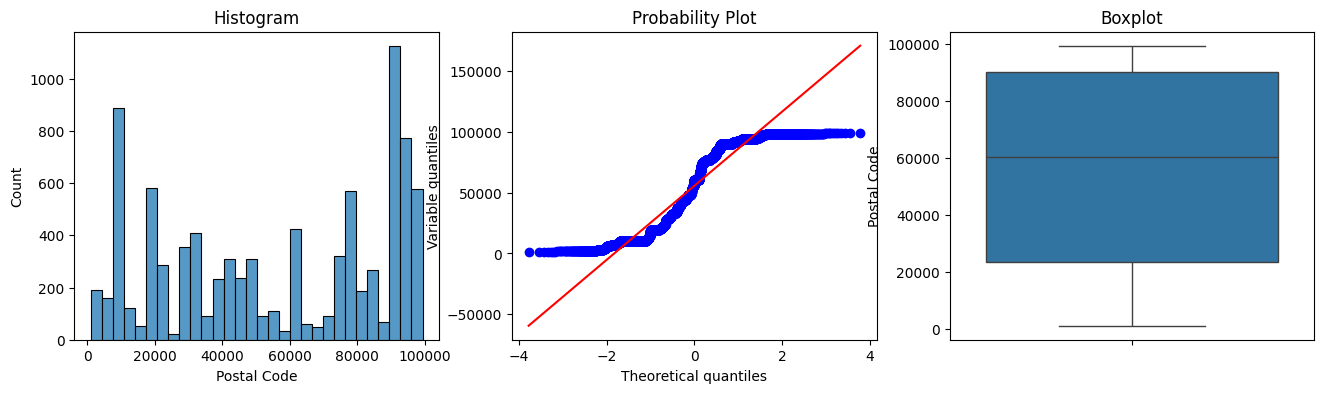

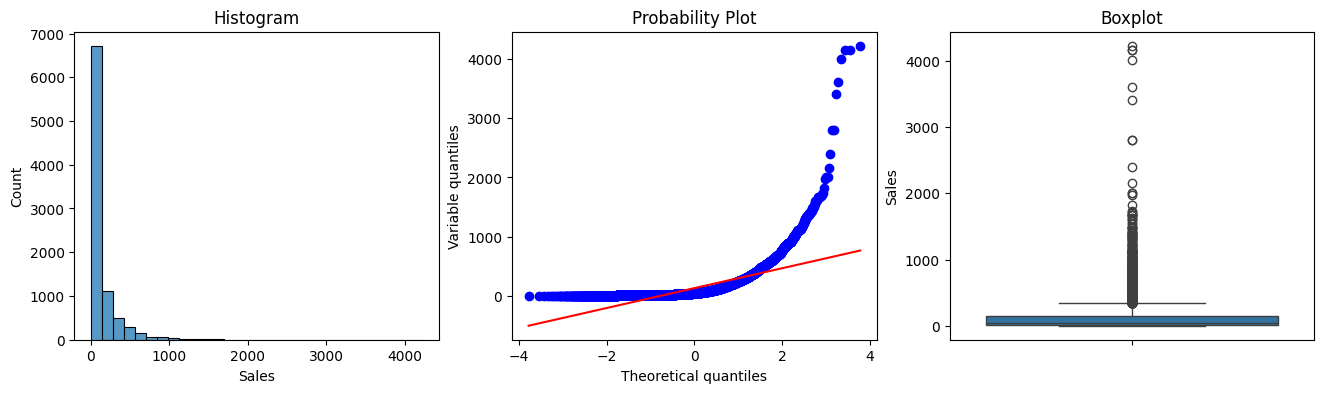

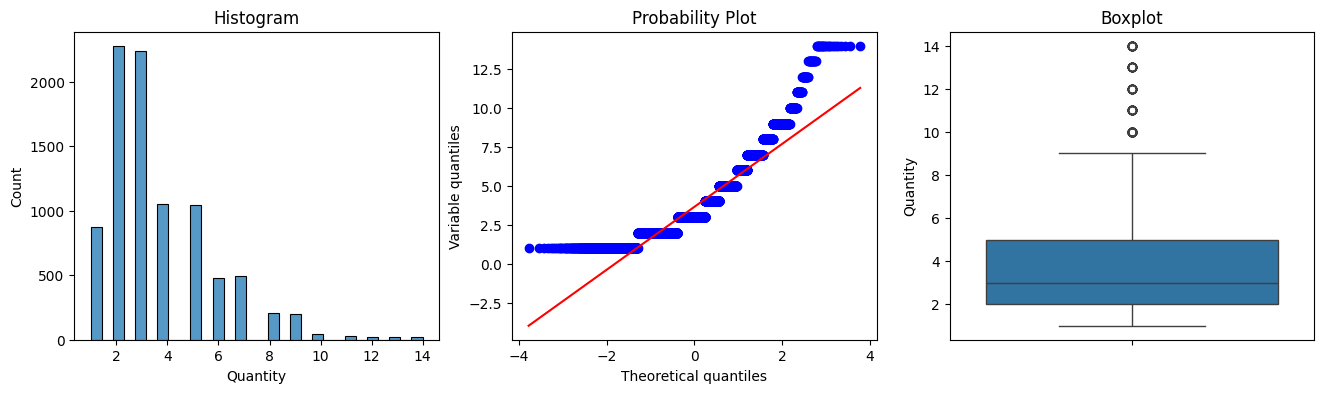

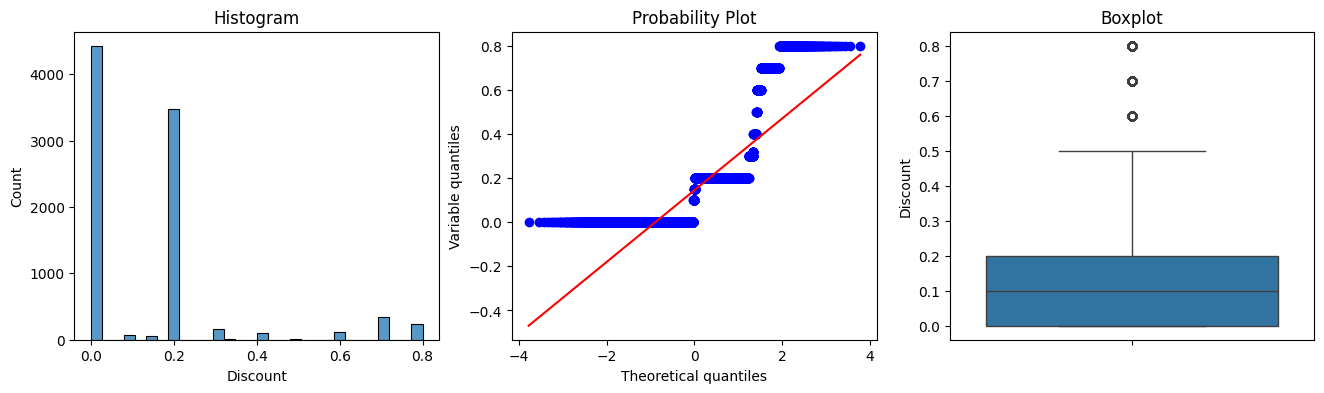

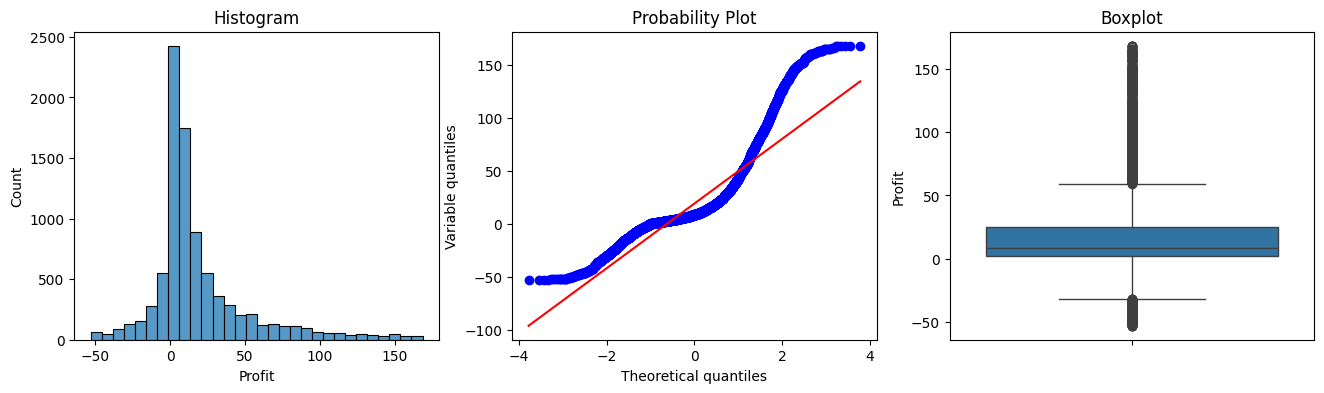

In [ ]:
for col in numerical_col:
  check_plot(df_filtered, col)

In [ ]:
# Export dataframe

# df.to_csv('df_superstore.csv', index=False)

#from google.colab import files
#files.download('df_superstore.csv')
